<a href="https://colab.research.google.com/github/dhanushreddy0726-ops/chocolateanalysis/blob/main/saleschocolatedata.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

     Sales Person    Country              Product       Date    Amount  \
0  Jehu Rudeforth         UK      Mint Chip Choco  04-Jan-22   $5,320    
1     Van Tuxwell      India        85% Dark Bars  01-Aug-22   $7,896    
2    Gigi Bohling      India  Peanut Butter Cubes  07-Jul-22   $4,501    
3    Jan Morforth  Australia  Peanut Butter Cubes  27-Apr-22  $12,726    
4  Jehu Rudeforth         UK  Peanut Butter Cubes  24-Feb-22  $13,685    

   Boxes Shipped  
0            180  
1             94  
2             91  
3            342  
4            184  
Total Sales: 6183625.0
Total Boxes Shipped: 177007


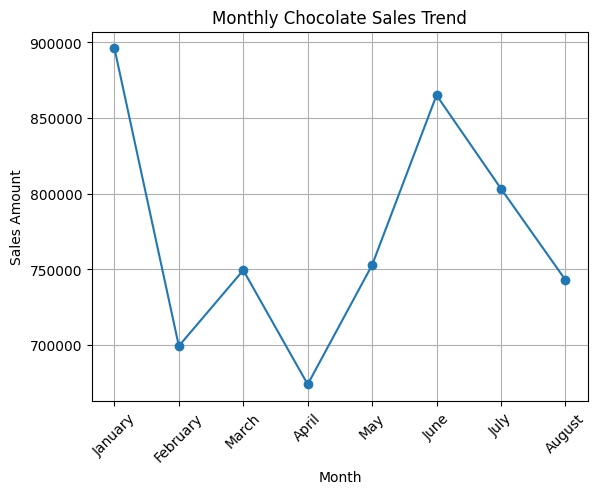

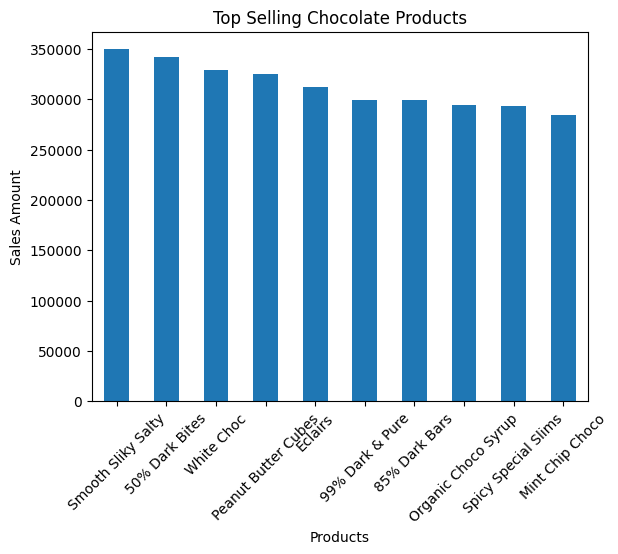

     Sales Person    Country              Product       Date   Amount  \
0  Jehu Rudeforth         UK      Mint Chip Choco 2022-01-04   5320.0   
1     Van Tuxwell      India        85% Dark Bars 2022-08-01   7896.0   
2    Gigi Bohling      India  Peanut Butter Cubes 2022-07-07   4501.0   
3    Jan Morforth  Australia  Peanut Butter Cubes 2022-04-27  12726.0   
4  Jehu Rudeforth         UK  Peanut Butter Cubes 2022-02-24  13685.0   

   Boxes Shipped     Month  
0            180   January  
1             94    August  
2             91      July  
3            342     April  
4            184  February  


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('/content/Chocolate Sales.csv')

print(data.head())

data['Amount'] = data['Amount'].replace(r'[$,]', '', regex=True).astype(float)

data['Date'] = pd.to_datetime(data['Date'], format='%d-%b-%y')

data['Month'] = data['Date'].dt.month_name()

total_sales = data['Amount'].sum()
total_boxes = data['Boxes Shipped'].sum()

print("Total Sales:", total_sales)
print("Total Boxes Shipped:", total_boxes)

monthly_sales = data.groupby('Month')['Amount'].sum()

month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

monthly_sales = monthly_sales.reindex(month_order)

monthly_sales.plot(kind='line', marker='o')

plt.xlabel("Month")
plt.ylabel("Sales Amount")
plt.title("Monthly Chocolate Sales Trend")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

top_products = data.groupby('Product')['Amount'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar')

plt.xlabel("Products")
plt.ylabel("Sales Amount")
plt.title("Top Selling Chocolate Products")
plt.xticks(rotation=45)

plt.show()

print(data.head())